# 04 · Validació independent amb altres xarxes (ACA i AEMET)

Fins ara, la qualitat del producte s'ha mesurat amb la mateixa XEMA que fa servir per corregir-se (notebook 03, *leave-one-out*). Aquí ho comprovem amb **pluviòmetres que el pipeline no fa servir mai**:

- **ACA** (Agència Catalana de l'Aigua): ~60 pluviòmetres de 5 min. Els que estan a < 1 km d'una XEMA són el mateix aparell (mateixos valors) i es tracten a part com a *duplicats*. La resta (~45) són independents.
- **AEMET**: ~80 estacions horàries. La recollida va començar el 4/10/2026, així que de moment només hi ha una mostra.

Preguntes:

1. **El producte final (taula ajustada + correcció XEMA) és tan bo com diu la validació *leave-one-out*?**
2. L'error creix lluny de les estacions XEMA?
3. **Val la pena afegir l'ACA a la correcció diària?**
4. Quins problemes de qualitat tenen les noves xarxes?

Dades: `validacio/parelles/` i `validacio/recomptes/` (XEMA) i `validacio/parelles_xarxes/` (ACA, AEMET), de l'1/8/2026 (inici de la calibració actual) endavant. Dia = 00–24 UTC per a totes les xarxes.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
import calibracio as C
C.estil()
pd.set_option('display.precision', 2); pd.set_option('display.width', 200)

df = C.control_qualitat_xarxes(C.carregar_xarxes())
print(f"{df.data.nunique()} dies ({df.data.min():%d/%m} – {df.data.max():%d/%m/%Y})")
df.groupby('xarxa').agg(estacions=('codi', 'nunique'), estacio_dies=('codi', 'size'),
                        descartats_qc=('qc_ok', lambda s: int((~s).sum())))

65 dies (01/08 – 04/10/2026)


,estacions,estacio_dies,descartats_qc
xarxa,,,
ACA,45,2681,16
AEMET,81,81,1
XEMA,187,12106,11


## 1 · Reproduïm el producte operatiu

Per poder provar variants (per exemple, afegir l'ACA a la correcció), refem la correcció local del pipeline amb `calibracio.correccio_local` (IDW 30 km + biaix mitjà com a pseudo-estació de pes 1/30²). Primer comprovem que, corregint **només amb la XEMA**, obtenim el mateix valor que el pipeline ha desat al píxel de cada pluviòmetre ACA.

In [2]:
ok = df.qc_ok.copy()
# Variant operativa: només la XEMA corregeix; ACA i AEMET només s'avaluen (leave-one-out per a la XEMA)
df['qc_ok'] = ok & (df.xarxa == 'XEMA')
df['corr_xema'] = C.correccio_local(df, 'taula', pes_mfb_km=30)
# Variant amb l'ACA: XEMA + ACA corregeixen (leave-one-out per a totes dues)
df['qc_ok'] = ok & df.xarxa.isin(['XEMA', 'ACA'])
df['corr_xema_aca'] = C.correccio_local(df, 'taula', pes_mfb_km=30)
df['qc_ok'] = ok

a = df[df.xarxa == 'ACA']
print(f"Correlació amb el producte operatiu: {np.corrcoef(a.corr_xema, a.radar_final_px)[0, 1]:.4f}; "
      f"quocient de totals: {a.corr_xema.sum() / a.radar_final_px.sum():.3f}")

Correlació amb el producte operatiu: 0.9998; quocient de totals: 1.003


La reproducció és pràcticament exacta, de manera que les variants que provem més avall són comparables amb el producte real.

## 2 · Control de qualitat de les noves xarxes

Fem servir els mateixos criteris que amb la XEMA (notebook 01), ara amb els veïns de totes les xarxes, i n'afegim un de nou:

- **zero sospitós**: l'estació marca 0, però els veïns i el radar ≥ 5 mm;
- **extrem sospitós**: > 30 mm i > 5 vegades els veïns i el radar;
- **pluja fantasma** (nou): ≥ 5 mm amb els veïns < 1 mm i el radar < 0,5 mm.

In [3]:
sosp = df[~df.qc_ok].sort_values(['xarxa', 'data'])
sosp[['data', 'xarxa', 'nom', 'obs', 'taula', 'mediana_veins', 'qc_flag']]

,data,xarxa,nom,obs,taula,mediana_veins,qc_flag
12183,2026-08-03,ACA,Embassament de La Llosa del Cavall (Cardener),0.0,33.51,15.45,zero_sospitos
12270,2026-08-05,ACA,Ripoll (Ter),10.2,0.00,0.00,pluja_fantasma
12443,2026-08-10,ACA,Esponellà (Fluvià),9.7,0.00,0.00,pluja_fantasma
12672,2026-08-16,ACA,Montblanc (Francolí),106.6,5.73,0.00,extrem_sospitos
13056,2026-08-27,ACA,Castellgalí (Cardener),10.4,0.05,0.00,pluja_fantasma
13302,2026-09-01,ACA,Embassament de Sant Ponç (Cardener),10.1,0.00,0.00,pluja_fantasma
13359,2026-09-03,ACA,Guardiola de Berguedà (Llobregat),10.0,0.00,0.00,pluja_fantasma
13683,2026-09-10,ACA,Súria (Cardener),10.4,0.00,0.00,pluja_fantasma
13853,2026-09-14,ACA,El Papiol (Llobregat),29.0,0.00,0.00,pluja_fantasma
13862,2026-09-14,ACA,Embassament de La Baells (Llobregat),10.5,0.00,0.00,pluja_fantasma


In [4]:
# Casos per revisar amb les dades de 5 min (eines/comprovar_xarxes.py pics)
casos = df[(df.xarxa == 'ACA') & (df.qc_flag == 'pluja_fantasma')][['data', 'codi', 'nom', 'obs']]
casos.assign(data=casos.data.dt.strftime('%Y-%m-%d')).to_csv('../validacio/xarxes/casos_pluja_fantasma.csv', index=False)
len(casos)

14

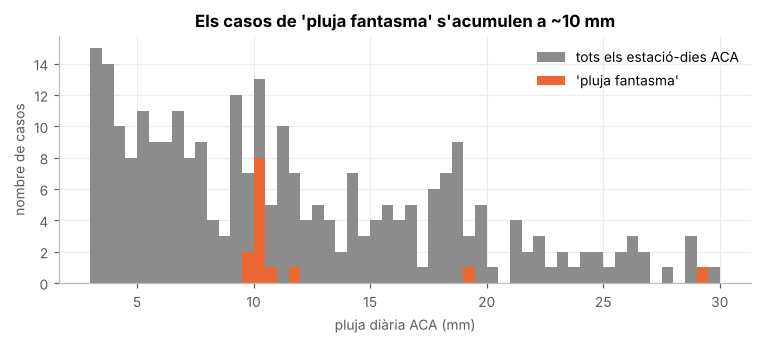

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.2))
v = df[(df.xarxa == 'ACA') & (df.obs >= 3) & (df.obs <= 30)]
bins = np.arange(3, 30.5, 0.5)
ax.hist(v.obs, bins=bins, color=C.COLORS['gris'], label='tots els estació-dies ACA')
ax.hist(v[v.qc_flag == 'pluja_fantasma'].obs, bins=bins, color=C.COLORS['taronja'], label="'pluja fantasma'")
ax.set_xlabel('pluja diària ACA (mm)'); ax.set_ylabel('nombre de casos'); ax.legend()
ax.set_title("Els casos de 'pluja fantasma' s'acumulen a ~10 mm")
fig.tight_layout(); fig.savefig('figures/04_pluja_fantasma.png', dpi=130)

Els casos de *pluja fantasma* de l'ACA no són a l'atzar: gairebé tots fan **~10 mm** (= un sol valor de 5 min de ~120 mm/h, amb radar i veïns a 0). Molt probablement és un valor erroni d'un sol interval (prova de manteniment, buidat del pluviòmetre...). Cal confirmar-ho amb les dades de 5 min d'aquests dies (`python eines/comprovar_xarxes.py pics`, a partir de `validacio/xarxes/casos_pluja_fantasma.csv`) i, si és així, filtrar els valors aïllats a `xarxes.py`. Mentrestant, el control de qualitat els exclou.

També hi ha algun cas real que el radar no veu (per exemple, el 21/8 a l'Empordà, amb ACA i XEMA de 7–18 mm i el radar a 0): aquests **no** es marquen, perquè els veïns també tenen pluja.

## 3 · Validació independent del producte final

Mètriques sobre els estació-dies amb pluja observada (≥ 1 mm) i que passen el control de qualitat:

- **ratio_total**: total estimat / total observat (1 = sense biaix);
- **r**: correlació;
- **MAE**: error mitjà absolut (mm/dia);
- **falses_alarmes_%**: % de dies secs a l'estació en què el producte dona ≥ 1 mm;
- **no_detectada_%**: % de dies amb ≥ 5 mm en què el producte dona < 1 mm.

Per comparar-ho, la XEMA amb *leave-one-out* (cada estació corregida sense la seva dada) sobre els mateixos dies.

In [6]:
q = df[df.qc_ok]
aca = q[(q.xarxa == 'ACA') & (q.duplicat_xema == 0)]
xema = q[q.xarxa == 'XEMA']
T = pd.concat({
    'ACA independents': C.taula_metriques(aca, ['radar_original_px', 'taula', 'radar_final_px']),
    'XEMA (leave-one-out)': C.taula_metriques(xema, ['taula', 'corr_xema']),
}).rename(index={'radar_original_px': 'taula antiga', 'taula': 'taula ajustada',
                 'radar_final_px': 'producte final', 'corr_xema': 'producte final'})
T

n  ratio_total     r    MAE   RMSE  biaix_mitja  falses_alarmes_%  no_detectada_%
ACA independents     taula antiga     403.0         0.40  0.68  12.55  22.79       -10.96              1.83            3.58
                     taula ajustada   403.0         0.77  0.79   9.62  17.37        -4.26              9.40            1.43
                     producte final   403.0         0.92  0.91   5.82  10.23        -1.40              6.18            2.15
XEMA (leave-one-out) taula ajustada  1799.0         0.81  0.72   8.81  17.43        -2.84              8.14            2.10
                     producte final  1799.0         0.88  0.88   5.95  11.54        -1.87              5.92            2.00

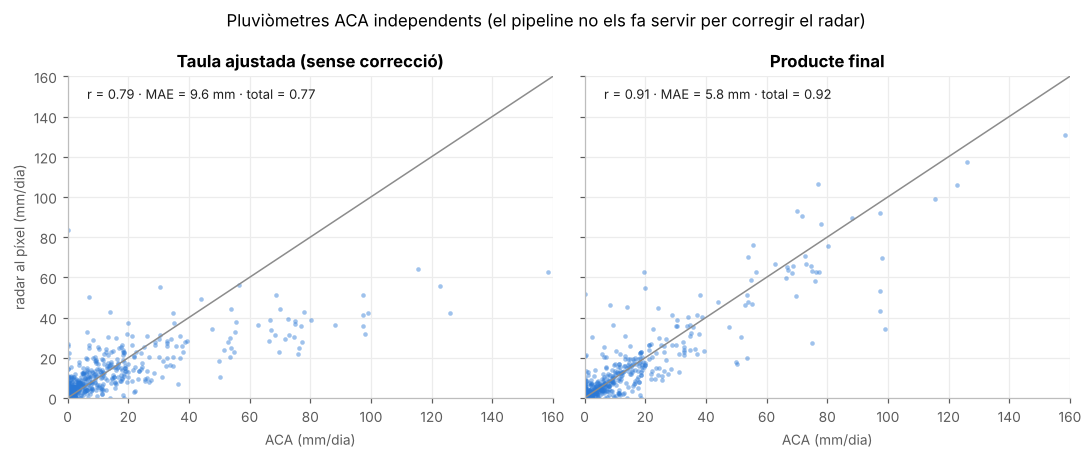

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4.2), sharex=True, sharey=True)
lim = 160
for ax, (col, tit) in zip(axs, [('taula', 'Taula ajustada (sense correcció)'), ('radar_final_px', 'Producte final')]):
    ax.scatter(aca.obs, aca[col], s=9, alpha=.45, color=C.COLORS['blau'], lw=0)
    ax.plot([0, lim], [0, lim], color=C.COLORS['gris'], lw=1)
    m = C.metriques(aca.obs, aca[col])
    ax.set_title(tit); ax.set_xlabel('ACA (mm/dia)')
    ax.text(.04, .93, f"r = {m.r:.2f} · MAE = {m.MAE:.1f} mm · total = {m.ratio_total:.2f}",
            transform=ax.transAxes, fontsize=8.5, color=C.COLORS['tinta'])
axs[0].set_ylabel('radar al píxel (mm/dia)')
axs[0].set_xlim(0, lim); axs[0].set_ylim(0, lim)
fig.suptitle('Pluviòmetres ACA independents (el pipeline no els fa servir per corregir el radar)', fontsize=11)
fig.tight_layout(); fig.savefig('figures/04_validacio_aca.png', dpi=130)

**Resultat principal:** als pluviòmetres de l'ACA, que el pipeline no fa servir, el producte final té pràcticament les mateixes mètriques que la validació *leave-one-out* amb la XEMA. Per tant, aquella validació **no era optimista**: és una bona estimació de l'error en un punt qualsevol del mapa.

La taula antiga donava menys de la meitat de la pluja real. Amb la taula ajustada i la correcció diària, el biaix és d'un ~10 % i l'error mitjà baixa a menys de la meitat.

Les xifres són pitjors que les del notebook 03 (MAE 4,3 mm), perquè aquí el període és només agost–octubre, amb molts episodis de pluja intensa, i el MAE creix amb la quantitat de pluja.

## 4 · L'error creix lluny de les estacions XEMA?

In [8]:
aca = aca.assign(dist=pd.cut(aca.dist_xema_km, [0, 3, 6, 10, 20],
                             labels=['1–3 km', '3–6 km', '6–10 km', '> 10 km']))
aca.groupby('dist').apply(lambda g: C.metriques(g.obs, g.radar_final_px)[['n', 'ratio_total', 'r', 'MAE']])

,n,ratio_total,r,MAE
dist,,,,
1–3 km,94.0,0.92,0.92,5.31
3–6 km,126.0,0.90,0.92,6.35
6–10 km,149.0,0.96,0.90,5.71
> 10 km,34.0,0.88,0.90,5.77


No s'hi veu una tendència clara. Amb la densitat de la XEMA, gairebé cap pluviòmetre ACA queda a més de 10 km d'una estació. A aquestes distàncies, el que domina l'error és la variabilitat de la pluja dins del mateix píxel i del mateix dia (sobretot en tempestes), més que no pas la distància a l'estació que corregeix.

## 5 · Totals mensuals

Percentatge d'estació-mesos (≥ 25 dies amb dada i ≥ 10 mm) en què el producte encerta el total mensual amb un error de ±25 %.

In [9]:
def encert_mensual(g, col):
    m = (g.assign(mes=g.data.dt.to_period('M'))
          .groupby(['codi', 'mes']).agg(obs=('obs', 'sum'), est=(col, 'sum'), n=('obs', 'size')))
    m = m[(m.n >= 25) & (m.obs >= 10)]
    return pd.Series({'estació-mesos': len(m), 'dins ±25 %': 100 * ((m.est / m.obs - 1).abs() <= .25).mean()})

qa = df[df.qc_ok & (df.xarxa == 'ACA') & (df.duplicat_xema == 0)]
qx = df[df.qc_ok & (df.xarxa == 'XEMA')]
pd.DataFrame({'ACA · taula antiga': encert_mensual(qa, 'radar_original_px'),
              'ACA · taula ajustada': encert_mensual(qa, 'taula'),
              'ACA · producte final': encert_mensual(qa, 'radar_final_px'),
              'XEMA · producte final (LOO)': encert_mensual(qx, 'corr_xema')}).T

,estació-mesos,dins ±25 %
ACA · taula antiga,75.0,20.00
ACA · taula ajustada,75.0,38.67
ACA · producte final,75.0,48.00
XEMA · producte final (LOO),278.0,41.73


## 6 · Val la pena afegir l'ACA a la correcció?

Comparem la correcció actual (només XEMA) amb una correcció que fa servir XEMA + ACA, totes dues amb *leave-one-out*. Ho avaluem a la XEMA i als ACA independents. L'interval de confiança de la diferència de MAE es calcula amb *bootstrap* per dies (els errors d'un mateix dia estan correlacionats).

In [10]:
def delta_mae(g, a='corr_xema', b='corr_xema_aca', n=2000, seed=0):
    g = g[g.obs >= 1]
    e = pd.DataFrame({'d': g.data, 'a': (g[a] - g.obs).abs(), 'b': (g[b] - g.obs).abs()})
    s = e.groupby('d')[['a', 'b']].sum(); k = e.groupby('d').size()
    rng = np.random.default_rng(seed)
    bs = []
    for _ in range(n):
        i = rng.choice(s.index, len(s))
        bs.append((s.loc[i, 'b'].sum() - s.loc[i, 'a'].sum()) / k.loc[i].sum())
    return pd.Series({'MAE només XEMA': e.a.mean(), 'MAE XEMA + ACA': e.b.mean(),
                      'diferència': e.b.mean() - e.a.mean(),
                      'IC95 inf': np.percentile(bs, 2.5), 'IC95 sup': np.percentile(bs, 97.5)})

R = pd.DataFrame({'avaluat a la XEMA': delta_mae(xema), 'avaluat als ACA independents': delta_mae(aca)}).T
R

,MAE només XEMA,MAE XEMA + ACA,diferència,IC95 inf,IC95 sup
avaluat a la XEMA,5.95,5.78,-0.18,-0.32,-0.03
avaluat als ACA independents,5.83,5.70,-0.14,-0.41,0.13


In [11]:
pd.concat({'XEMA': C.taula_metriques(xema, ['corr_xema', 'corr_xema_aca']),
           'ACA independents': C.taula_metriques(aca, ['corr_xema', 'corr_xema_aca'])}
          ).rename(index={'corr_xema': 'només XEMA', 'corr_xema_aca': 'XEMA + ACA'})

n  ratio_total     r   MAE   RMSE  biaix_mitja  falses_alarmes_%  no_detectada_%
XEMA             només XEMA  1799.0         0.88  0.88  5.95  11.54        -1.87              5.92            2.00
                 XEMA + ACA  1799.0         0.87  0.88  5.78  11.31        -1.92              6.24            1.90
ACA independents només XEMA   403.0         0.93  0.91  5.83  10.22        -1.35              6.23            2.15
                 XEMA + ACA   403.0         0.92  0.92  5.70   9.94        -1.52              6.63            2.15

Afegir l'ACA a la correcció **millora una mica** el producte: ~0,15 mm/dia de MAE, un ~3 %. A la XEMA la millora és estadísticament significativa. Als ACA també apunta en la mateixa direcció, però amb menys casos l'interval inclou el zero. La correlació i el biaix no canvien.

És una millora petita perquè la XEMA ja és densa. On l'ACA aporta més és en conques de capçalera sense XEMA a prop. A canvi, cal un bon control de qualitat de l'ACA (pluja fantasma, avaries com la de Sau el 29/9): un pluviòmetre erroni que entra a la correcció afecta el mapa en 30 km a la rodona.

**Recomanació:** abans d'afegir l'ACA a la correcció, (1) confirmar i filtrar els valors aïllats de 5 min a `xarxes.py`, (2) aplicar-hi aquest mateix control de qualitat diari i (3) repetir aquesta comparació amb més mesos, sobretot amb pluges de tardor i hivern, més generalitzades. Si la millora es manté, activar-la és un canvi petit al pipeline.

## 7 · Pluviòmetres ACA duplicats de la XEMA

Els 10 pluviòmetres ACA a < 1 km d'una XEMA donen els mateixos valors que la XEMA. Al seu píxel, el producte final ja està corregit amb aquella mateixa estació, per això les mètriques són tan bones. No serveixen per validar, i per això s'exclouen de tota la resta de l'anàlisi.

In [12]:
tot = C.carregar_xarxes()   # sense control de qualitat, que exclou els duplicats
dup = tot[(tot.xarxa == 'ACA') & (tot.duplicat_xema == 1)]
C.taula_metriques(dup, ['taula', 'radar_final_px']).rename(index={'taula': 'taula ajustada', 'radar_final_px': 'producte final'})

,n,ratio_total,r,MAE,RMSE,biaix_mitja,falses_alarmes_%,no_detectada_%
taula ajustada,108.0,0.96,0.69,9.19,15.00,-0.59,8.73,1.52
producte final,108.0,1.01,0.99,1.31,2.83,0.20,6.44,1.52


## 8 · AEMET (mostra preliminar)

La recollida horària d'AEMET va començar el 4/10/2026. Aquesta secció s'actualitza sola a mesura que hi hagi més dies. Amb menys de ~30 dies de pluja, les xifres no són representatives: un sol episodi (el 4/10, amb pluja generalitzada) domina el resultat.

In [13]:
ae = df[(df.xarxa == 'AEMET') & df.qc_ok]
print(f"AEMET: {ae.data.nunique()} dies, {ae.codi.nunique()} estacions, {int((ae.obs >= 1).sum())} estació-dies amb pluja")
if (ae.obs >= 1).sum() >= 5:
    display(C.taula_metriques(ae, ['radar_original_px', 'taula', 'radar_final_px']).rename(
        index={'radar_original_px': 'taula antiga', 'taula': 'taula ajustada', 'radar_final_px': 'producte final'}))

AEMET: 1 dies, 80 estacions, 37 estació-dies amb pluja


,n,ratio_total,r,MAE,RMSE,biaix_mitja,falses_alarmes_%,no_detectada_%
taula antiga,37.0,0.23,0.90,39.67,53.88,-39.67,0.00,0.0
taula ajustada,37.0,0.50,0.87,27.63,40.83,-25.75,2.94,0.0
producte final,37.0,1.02,0.98,6.28,8.91,1.04,0.00,0.0


## Conclusions

1. **La validació independent amb l'ACA confirma la del notebook 03.** Als pluviòmetres que el pipeline no fa servir, el producte final té el mateix error que la XEMA amb *leave-one-out*: total ~0,9 del real i correlació ~0,9 en aquest període. La calibració no està sobreajustada a la XEMA.
2. **L'error gairebé no depèn de la distància a la XEMA** dins del rang que tenim (< 15 km). Domina la variabilitat de la pluja dins d'un mateix píxel.
3. **Afegir l'ACA a la correcció millora poc** (~3 % de MAE). No ho activem encara: primer cal filtrar els seus errors i confirmar-ho amb més mesos.
4. **L'ACA té un artefacte recurrent de ~10 mm aïllats** que cal filtrar a l'origen.
5. **AEMET**: pendent d'acumular dades. Serà la validació independent de referència, perquè no comparteix cap aparell amb la XEMA.